In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pathlib
import sys

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [2]:
churn_data=pd.read_csv("Churndata.csv")


In [3]:
churn_data["TotalCharges"] = pd.to_numeric(churn_data["TotalCharges"], errors='coerce')
churn_data["MonthlyCharges"] = pd.to_numeric(churn_data["MonthlyCharges"], errors='coerce')

In [4]:
churn_data["SeniorCitizen"] = churn_data["SeniorCitizen"].map({1: "Yes", 0: "No"})

In [5]:
churn_data["Churn"] = churn_data["Churn"].map({"No": 0, "Yes": 1})


In [6]:
print("\nMissing values:")
print(churn_data.isnull().sum())


Missing values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [7]:
churn_data = churn_data.dropna(subset=["TotalCharges"])

if "customerID" in churn_data.columns:
    churn_data = churn_data.drop(columns=["customerID"])

In [8]:
print(churn_data.isnull().sum())
print(churn_data.shape)

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
(7032, 20)


In [9]:
X = churn_data.drop(columns=["Churn"])
y = churn_data["Churn"]

# Separate numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumeric columns:", numeric_features)
print("Categorical columns:", categorical_features)


Numeric columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, random_state=42, class_weight="balanced"
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=400, random_state=42, class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []
fitted_models = {}


In [13]:
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV_Accuracy": scores["test_accuracy"].mean(),
        "CV_Precision": scores["test_precision"].mean(),
        "CV_Recall": scores["test_recall"].mean(),
        "CV_F1": scores["test_f1"].mean(),
        "CV_ROC_AUC": scores["test_roc_auc"].mean()
    })

    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline

results_churn = pd.DataFrame(cv_results).sort_values(by="CV_F1", ascending=False)

print("\nCross-Validated Model Comparison:")
print(results_churn)




Cross-Validated Model Comparison:
                 Model  CV_Accuracy  CV_Precision  CV_Recall     CV_F1  \
0  Logistic Regression     0.752000      0.521841   0.802007  0.632209   
3    Gradient Boosting     0.800000      0.657112   0.517726  0.578781   
4                  KNN     0.768356      0.566716   0.544482  0.555267   
1        Random Forest     0.790222      0.639489   0.482943  0.549987   
2          Extra Trees     0.769600      0.582910   0.466221  0.517862   

   CV_ROC_AUC  
0    0.845948  
3    0.847324  
4    0.797018  
1    0.825861  
2    0.791694  



Best model based on Accuracy: Logistic Regression
Best CV F1: 0.6322

Test Set Metrics:
Accuracy: 0.7257
Precision: 0.4901
Recall: 0.7968
F1 Score: 0.6069
ROC AUC: 0.8351

Classification Report:
              precision    recall  f1-score   support

        Stay       0.90      0.70      0.79      1033
       Leave       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



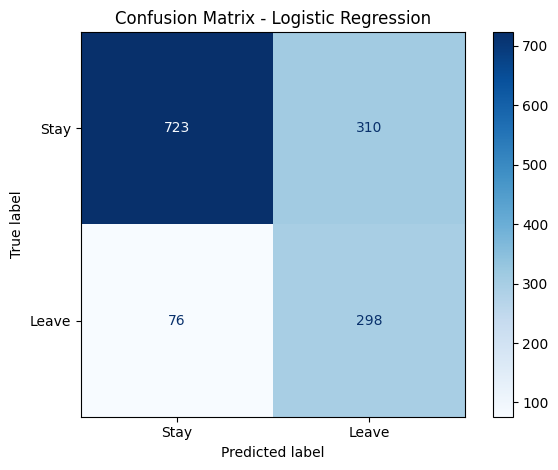

In [14]:
best_model_name = results_churn.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

print(f"\nBest model based on Accuracy: {best_model_name}")
print(f"Best CV F1: {results_churn.iloc[0]['CV_F1']:.4f}")

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model.named_steps["model"], "predict_proba") else None

print("\nTest Set Metrics:")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
if y_prob is not None:
    print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Stay", "Leave"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stay", "Leave"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()


In [15]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=15,
    random_state=42,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm.importances_mean
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 most important factors affecting churn:")
print(importance_df.head(10))

most_important_factor = importance_df.iloc[0]["Feature"]
print(f"\nMost important factor affecting churn: {most_important_factor}")



Top 10 most important factors affecting churn:
            Feature    Importance
4            tenure  8.775172e-02
17   MonthlyCharges  1.852642e-02
7   InternetService  1.492537e-02
18     TotalCharges  9.049988e-03
16    PaymentMethod  6.633499e-04
5      PhoneService  2.220446e-17
12      StreamingTV -4.738214e-05
1     SeniorCitizen -1.421464e-04
14         Contract -4.264392e-04
0            gender -6.633499e-04

Most important factor affecting churn: tenure


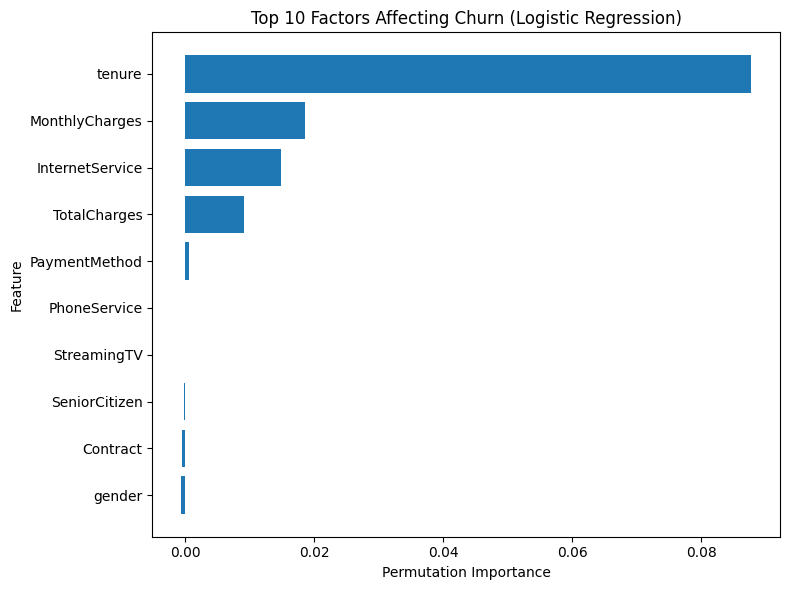

In [16]:
top_n = 10
top_features = importance_df.head(top_n).sort_values(by="Importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title(f"Top {top_n} Factors Affecting Churn ({best_model_name})")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# Risk bands: C++ implementation (ctypes). Build shared lib from repo root:
_here = pathlib.Path.cwd().resolve()
if (_here / "src" / "cpp_engine" / "churn_risk.cpp").exists():
    PROJECT_ROOT = _here
else:
    PROJECT_ROOT = _here.parent
sys.path.insert(0, str(PROJECT_ROOT / "src" / "cpp_engine"))
from churn_risk_ctypes import risk_band as _risk_band_cpp

results = X_test.copy()
results["Actual_Churn"] = y_test.values
results["Predicted_Churn"] = y_pred

if y_prob is not None:
    results["Churn_Probability"] = y_prob
else:
    results["Churn_Probability"] = np.nan

results["Predicted_Label"] = results["Predicted_Churn"].apply(lambda x: "Leave" if x == 1 else "Stay")
results["Actual_Label"] = results["Actual_Churn"].apply(lambda x: "Leave" if x == 1 else "Stay")

results["Risk_Level"] = results["Churn_Probability"].apply(
    lambda p: _risk_band_cpp(p, project_root=PROJECT_ROOT)
)

print("\nSample Predictions:")
print(results[["Actual_Label", "Predicted_Label", "Churn_Probability", "Risk_Level"]].head(10))



Sample Predictions:
     Actual_Label Predicted_Label  Churn_Probability   Risk_Level
974          Stay            Stay           0.050761     Low Risk
619          Stay           Leave           0.785200    High Risk
4289         Stay            Stay           0.014230     Low Risk
3721        Leave            Stay           0.401228  Medium Risk
4533         Stay            Stay           0.231603     Low Risk
445         Leave           Leave           0.723141    High Risk
5898         Stay            Stay           0.072739     Low Risk
3387         Stay            Stay           0.348828     Low Risk
1346        Leave           Leave           0.845941    High Risk
5690         Stay            Stay           0.047047     Low Risk


In [ ]:
# customers most likely to leave
# Highest risk customers
high_risk_customers = results.sort_values("Churn_Probability", ascending=False)
print("\nTop 20 Highest Risk Customers:")
print(high_risk_customers[["Actual_Label", "Predicted_Label", "Churn_Probability", "Risk_Level"]].head(20))


In [ ]:
results.to_csv("churn_predictions.csv", index=False)

print("Prediction file saved successfully as churn_predictions.csv")